In [56]:
import matplotlib.pyplot as plt

# Renomeando a variável resposta para facilitar a leitura do código
df = df.rename(columns={
    "default payment next month": "DEFAULT"
})

# Frequências absolutas
print(df["DEFAULT"].value_counts())

# Frequências relativas
print(df["DEFAULT"].value_counts(normalize=True))

DEFAULT
0    23364
1     6636
Name: count, dtype: int64
DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [10]:
df.isna().sum()
df['ID'].duplicated().sum()

np.int64(0)

In [57]:
df.groupby("EDUCATION")["DEFAULT"].mean().sort_index()

EDUCATION
0    0.000000
1    0.192348
2    0.237349
3    0.251576
4    0.056911
5    0.064286
6    0.156863
Name: DEFAULT, dtype: float64

In [58]:
df["PAY_0"].value_counts().sort_index()

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

In [3]:
df.groupby("PAY_0")["DEFAULT"].mean()

NameError: name 'df' is not defined

In [60]:
df["EDUCATION"].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [61]:
df.groupby("MARRIAGE")["DEFAULT"].mean().sort_index()

MARRIAGE
0    0.092593
1    0.234717
2    0.209283
3    0.260062
Name: DEFAULT, dtype: float64

In [62]:
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

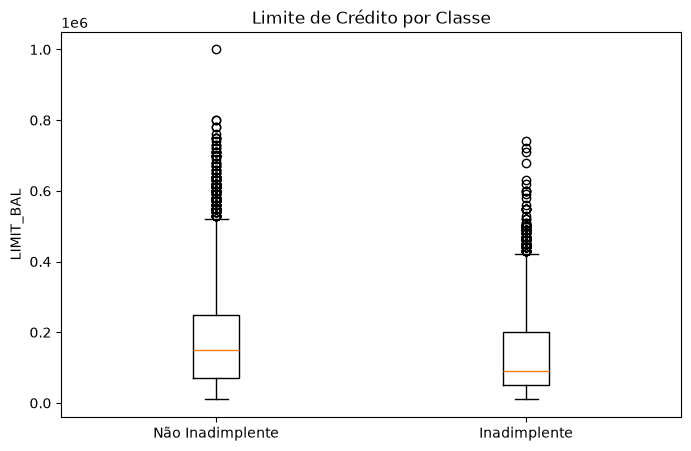

In [63]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        df[df["DEFAULT"] == 0]["LIMIT_BAL"],
        df[df["DEFAULT"] == 1]["LIMIT_BAL"]
    ],
    tick_labels=["Não Inadimplente", "Inadimplente"]
)

plt.title("Limite de Crédito por Classe")
plt.ylabel("LIMIT_BAL")

plt.show()

In [64]:
df.groupby("SEX")["DEFAULT"].mean()

SEX
1    0.241672
2    0.207763
Name: DEFAULT, dtype: float64

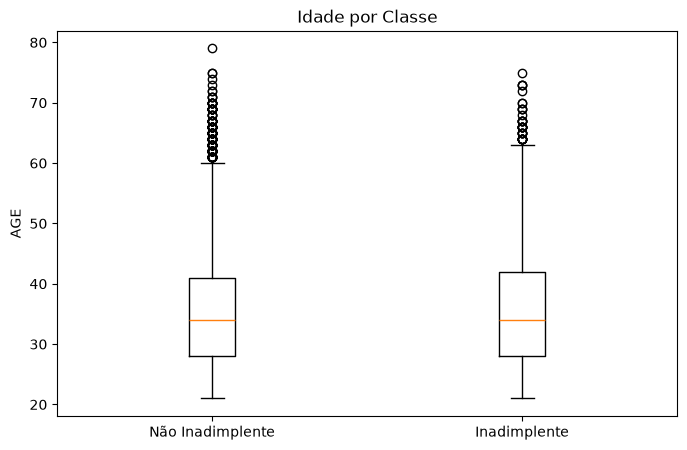

In [65]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        df[df["DEFAULT"] == 0]["AGE"],
        df[df["DEFAULT"] == 1]["AGE"]
    ],
    tick_labels=["Não Inadimplente", "Inadimplente"]
)

plt.title("Idade por Classe")
plt.ylabel("AGE")

plt.show()

C:\Users\T-Gamer\AppData\Local\Temp\ipykernel_10812\3447751662.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["LIMIT_BAL"], vert=False)


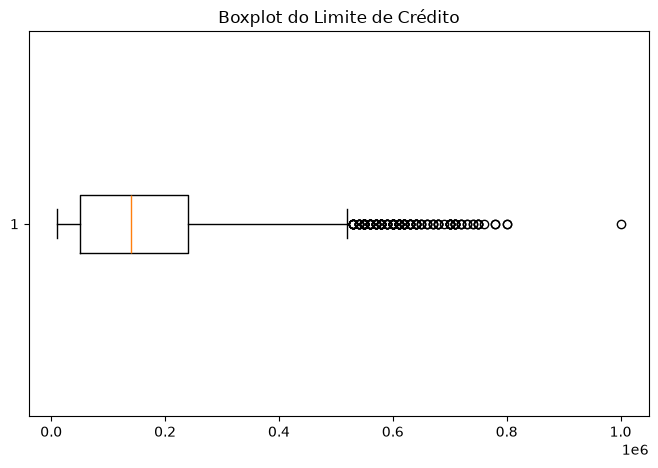

In [66]:
plt.figure(figsize=(8,5))

plt.boxplot(df["LIMIT_BAL"], vert=False)

plt.title("Boxplot do Limite de Crédito")

plt.show()

## 2.2 Distribuição das variáveis numéricas

Nesta etapa analisamos as distribuições das principais variáveis numéricas para identificar assimetria, concentração de valores e possíveis comportamentos incomuns.

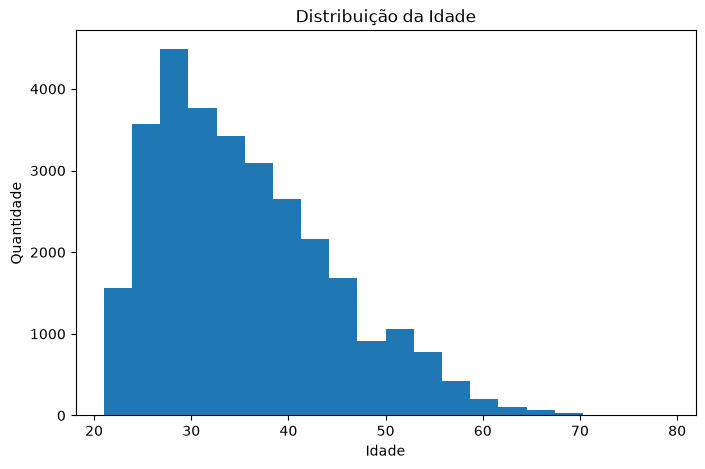

In [67]:
plt.figure(figsize=(8,5))

plt.hist(df["AGE"], bins=20)

plt.title("Distribuição da Idade")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

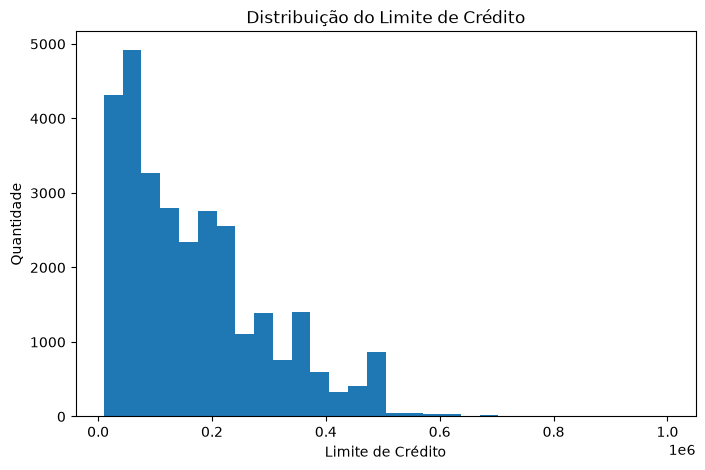

In [68]:
plt.figure(figsize=(8,5))

plt.hist(df["LIMIT_BAL"], bins=30)

plt.title("Distribuição do Limite de Crédito")
plt.xlabel("Limite de Crédito")
plt.ylabel("Quantidade")

plt.show()

C:\Users\T-Gamer\AppData\Local\Temp\ipykernel_10812\260958365.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["AGE"], vert=False)


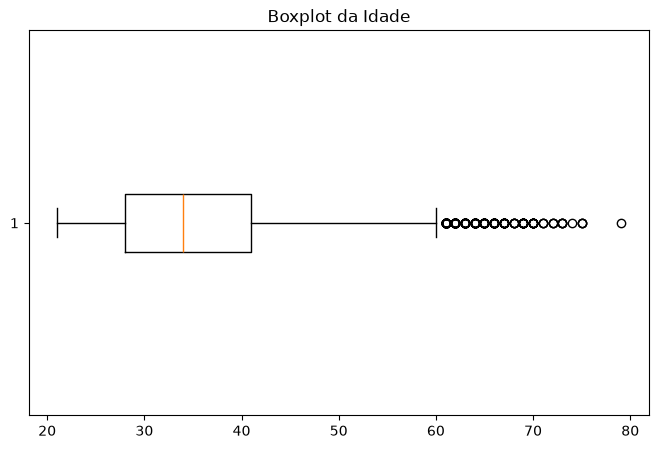

In [69]:
plt.figure(figsize=(8,5))

plt.boxplot(df["AGE"], vert=False)

plt.title("Boxplot da Idade")

plt.show()

In [70]:
df[["AGE", "LIMIT_BAL"]].skew()

AGE          0.732246
LIMIT_BAL    0.992867
dtype: float64

In [7]:
# Frequências absolutas
print(df["DEFAULT"].value_counts())

# Frequências relativas
print(df["DEFAULT"].value_counts(normalize=True))

KeyError: 'DEFAULT'

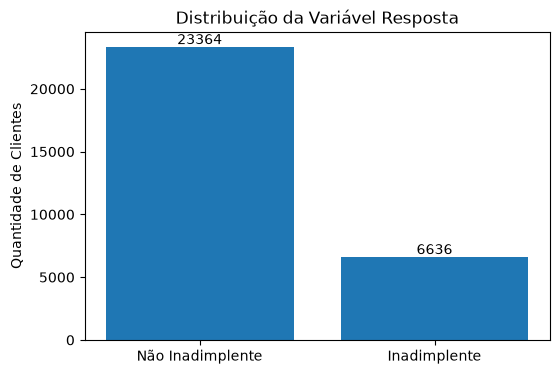

In [72]:
counts = df["DEFAULT"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ["Não Inadimplente", "Inadimplente"],
    counts.values
)

plt.title("Distribuição da Variável Resposta")
plt.ylabel("Quantidade de Clientes")

for i, valor in enumerate(counts.values):
    plt.text(i, valor + 200, str(valor), ha="center")

plt.show()

In [73]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='str')

## 2.1 Análise da variável resposta (DEFAULT)

Antes de treinar qualquer modelo de classificação, é importante compreender a distribuição da variável resposta.

Nesta etapa verificaremos:

- quantidade de clientes inadimplentes;
- proporção entre as classes;
- possível desbalanceamento dos dados.

Essas informações serão importantes para a escolha das métricas de avaliação do modelo.

In [74]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   30000 non-nu

In [76]:
df.shape

(30000, 25)

In [77]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [78]:
df.iloc[:5]

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [1]:
import pandas as pd

df = pd.read_excel(
    "C:/Users/T-Gamer/Desktop/igor/credit-default-api/data/raw/default_of_credit_card_clients.xls",
    header=1)

# Credit Default Prediction

## Data Understanding

Objetivo desta etapa:
- Carregar o dataset
- Entender as variáveis
- Identificar problemas de qualidade dos dados
- Levantar hipóteses antes da modelagem

ID: Identificador único do cliente

LIMIT_BALL: Limite de crédito concedido ao cliente

SEX, EDUCATION, MARRIAGE, AGE: dados demográficos, características do cliente

PAY_0 a PAY_6: Status de pagamento dos últimos meses, PAY_0 é Setembro de 2005, PAY_2 é Agosto de 2005, PAY_3 é Julho de 2005, PAY_4 é Junho de 2005, PAY_5 é Maio de 2005, PAY_6 é Abril de 2005, os valores significam: -2 Sem fatura naqueel mês, -1 Pagou fatura em dia, 0 Pagou com atraso de até 1 mês, 1 Atraso de um mês, 2 Atraso de dois meses, 3 Atraso de três meses... e por assim vai.

BILL_AMT1 a BILL_AMT6: Representam o valor da fatura do cartão em cada um dos últimos seis meses

PAY_ANT1 a PAY_ANT6: Representam o valor efetivamente pago pelo cliente

default.payment.next.month: variável resposta. 1=cliente entrou em inadimplência no mês seguinte, 0=cliente não entrou em inadimplência.
